In [ ]:
#| default_exp prototypical_ex

In [ ]:
#| hide

import plotly.io as pio

In [ ]:
#| hide
pio.renderers.default = "png"

# Denoising Variational Auto-Encoder

## Install the External Package

In [ ]:
#| eval: false
!pip install dvae;


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: pip install --upgrade pip


## Import Data
> to skip the first three steps of the [basic workflow](./module_functions_ex.ipynb#obtain_input_data): Obtain, Prepare, Split and Scale

In [ ]:
#| eval: false
from nbdev_fhemb.module_functions_ex import X_train, X_test, y_train, y_test

DEBUG:fhemb.config.settings:Loading environment from /Users/radned/.config/fhemb/.env.paths
DEBUG:fhemb.config.settings:Loading environment from /Users/radned/.config/fhemb/.env.db
DEBUG:fhemb.config.settings:Running locally
 [DEBUG] mixins.wrapper: wrapper of process_subjects called with subjs=[(40, 44), (47, 52), 53, 54, (56, 71), (73, 75)], args=() and kwargs={'title': 'Don Giovanni', 'time_interval': (14200, 15200)}
 [DEBUG] mixins.wrapper: Calling: get_piece_attribute_values with title=Don Giovanni and atributes=['number_of_subjects']
 [DEBUG] mixins.wrapper: to get subjects_int from 'number_of_subjects' record in performance_library
 [DEBUG] mixins.wrapper: Calling: __init__ with subjs=[40, 41, 42, 43, 44, 47, 48, 49, 50, 51, 52, 53, 54, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 73, 74, 75] and args=() and kwargs={'title': 'Don Giovanni', 'time_interval': (14200, 15200)}
 [DEBUG] piece.__init__: Processed subjects: [40, 41, 42, 43, 44, 47, 48, 49, 50, 51, 52

In [ ]:
#| hide
#| eval: false

X_train.shape, X_test.shape

((44, 250, 1), (20, 250, 1))

## Train and Test

### Train and test in two steps
> using `fit` and `predict` separately

#### Define the classifier 

In [ ]:
#| eval: false
from dvae.classifier import VAEClassifier

In [ ]:
#| eval: false
clf1 = VAEClassifier(
    feature_dim=250,
    z_dim=80,
    hidden_dim=80,
    alpha1=1e-5,
    alpha2=1,
    beta=1e-2,
    corruption=0.0,
    seed=42,
)

#### 1. Fit the classifier to the training data

In [ ]:
#| eval: false
clf1.fit(X_train.squeeze(), y_train.squeeze(), num_epochs=1000)

,feature_dim,250


#### 2. Use the trained classifier to predict the labels of the test data

In [ ]:
#| eval: false

y_pred1 = clf1.predict(X_test.squeeze())

#### Evaluate the performance of the classifier

In [ ]:
#| eval: false
from fhemb.utils.cutils import calc_similarity

In [ ]:
#| eval: false
calc_similarity(y_test, y_pred1, sim_metric='f1')

0.6491228070175439

In [ ]:
#| eval: false
calc_similarity(y_test, y_pred1, sim_metric='accuracy')

0.65

### Train and test in one step
> using `fit` and `predict` in one step as `fit_predict_on`

#### Define the classifier

In [ ]:
#| eval: false
clf2 = VAEClassifier(
    feature_dim=250,
    z_dim=80,
    hidden_dim=80,
    alpha1=1e-5,
    alpha2=1,
    beta=1e-2,
    corruption=0.0,
    seed=42,
)

#### Fit and predict
> in one step

In [ ]:
#| eval: false
y2_pred = clf2.fit_predict_on(X_train.squeeze(), y_train.squeeze(), X_test.squeeze(), num_epochs=1000)

 [WARNING] src.utils.logger._propose_threshold: Multiple best accuracies: [0.5        0.5        0.5        0.5        0.5        0.5
 0.97727273 0.97727273 0.97727273 0.97727273 0.97727273 0.97727273
 0.79545455 0.5        0.5        0.5        0.5        0.5       ]


#### Evaluate the performance of the classifier

In [ ]:
#| eval: false
calc_similarity(y_test, y2_pred, sim_metric='f1')

0.6

In [ ]:
#| eval: false
calc_similarity(y_test, y2_pred, sim_metric='accuracy')

0.6

## Diagnostics via Pairwise Relation and Dimensionality Reduction


### Get the latent space of the trained classifier

In [ ]:
#| eval: false
z_all1 = clf1.vae.z_loc_embedding

### Projection of the latent space into a 3D space

#### UMAP projection

In [ ]:
#| eval: false

!pip install umap-learn;


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: pip install --upgrade pip


In [ ]:
#| eval: false

from sklearn.manifold import TSNE
from umap import UMAP
from sklearn.decomposition import PCA

In [ ]:
#| eval: false

umap1=UMAP(n_components=3, random_state=0)
reduced_umap1=umap1.fit_transform(z_all1)

/Users/radned/.pyenv/versions/p311.fhemb/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [ ]:
#| eval: false
import matplotlib.pyplot as plt

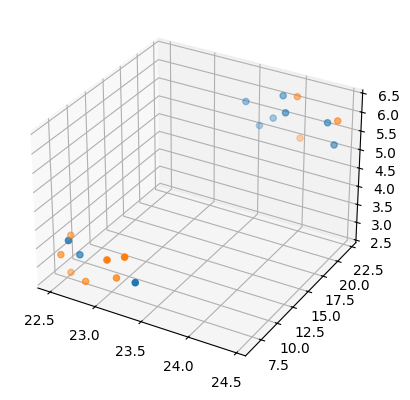

In [ ]:
#| eval: false

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.scatter(reduced_umap1[y_test==0, 0], reduced_umap1[y_test==0, 1], reduced_umap1[y_test==0, 2])
ax.scatter(reduced_umap1[y_test==1, 0], reduced_umap1[y_test==1, 1], reduced_umap1[y_test==1, 2])
plt.show()


#### PCA projection

In [ ]:
#| eval: false

pca1=PCA(n_components=3, random_state=0)
reduced_pca1=pca1.fit_transform(z_all1)

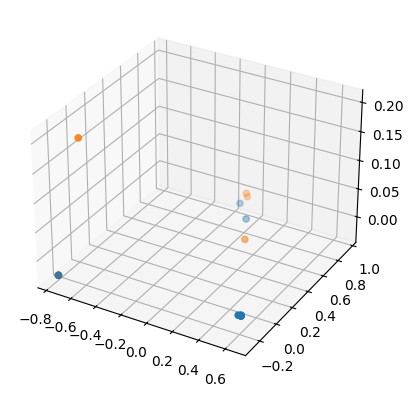

In [ ]:
#| eval: false

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.scatter(reduced_pca1[y_test==0, 0], reduced_pca1[y_test==0, 1], reduced_pca1[y_test==0, 2])
ax.scatter(reduced_pca1[y_test==1, 0], reduced_pca1[y_test==1, 1], reduced_pca1[y_test==1, 2])
plt.show()

### Projection of a pairwise relation embedding of the latent space into a 3D space

In [ ]:
#| eval: false
from fhemb.utils.cutils import plot_pr_projection

 [DEBUG] cutils.calc_pairwise_relation: Using distance correlation
 [DEBUG] cutils.calc_pr_matrix: Computing pairwise relation matrix for symmetric data
Computing distances:   4%|▍         | 8/210 [00:18<00:16, 12.07it/s]/Users/radned/.pyenv/versions/p311.fhemb/lib/python3.11/site-packages/dcor/_fast_dcov_avl.py:554: UserWarning: Falling back to uncompiled AVL fast distance covariance terms because of TypeError exception raised: No matching definition for argument type(s) array(float32, 1d, C), array(float32, 1d, C), bool. Rembember: only floating point values can be used in the compiled implementations.
  warnings.warn(
Computing distances:   8%|▊         | 16/210 [00:24<05:52,  1.82s/it]/Users/radned/.pyenv/versions/p311.fhemb/lib/python3.11/site-packages/dcor/_fast_dcov_avl.py:554: UserWarning: Falling back to uncompiled AVL fast distance covariance terms because of TypeError exception raised: No matching definition for argument type(s) array(float32, 1d, C), array(float32, 1d, C), 

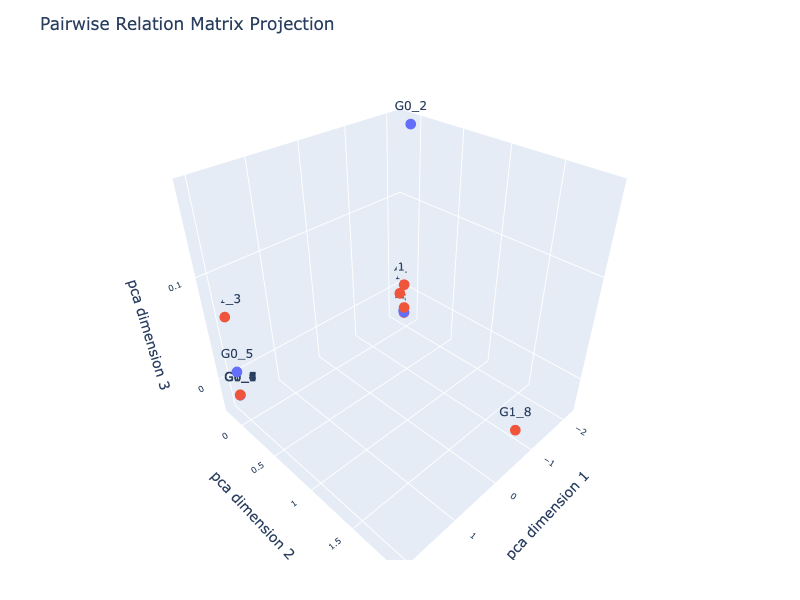

In [ ]:
#| eval: false

plot_pr_projection(
    z_all1[y_test==0],
    z_all1[y_test==1],           # data matrices for two groups 
    alignment_type='dcor',       # distance correlation by Székely, Rizzo, and Bakirov (2007)            
    projection='pca',            # projection method for dimensionality reduction ('pca', 'tsne', 'mds', 'umap') 
    transformation='minmax',     # to transform distances into similarities for PCA
    normalize='l1',              # normalization method for distance matrix
    n_jobs=8,                    # number of jobs for parallelization
    dimensions=3,                # number of dimensions of the projection
) 